# Quick GraphCast Inference Demo

This notebook runs a short GraphCast inference workflow using a local GraphCast checkpoint, example ERA5 input data, and GraphCast normalization statistics.

**Workflow**

1. Load the GraphCast checkpoint and configuration.
2. Load a small example ERA5 batch and prepare inputs, targets, and forcings.
3. Load normalization statistics.
4. Build the wrapped GraphCast predictor and JAX-jitted inference function.
5. Run a short autoregressive rollout.

> **Note:** This version is organized for presentation and reproducibility. It assumes the checkpoint, sample dataset, and normalization files are available under `../checkpoints` relative to the notebook working directory.


## 1. Imports and runtime setup

Keep all imports in one place so the runtime requirements are easy to review before running the workflow.


In [1]:
import dataclasses
import functools
from pathlib import Path

import haiku as hk
import jax
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from graphcast import autoregressive
from graphcast import casting
from graphcast import checkpoint
from graphcast import data_utils
from graphcast import graphcast
from graphcast import normalization
from graphcast import rollout
from graphcast import xarray_jax
from graphcast import xarray_tree

plt.rcParams["figure.figsize"] = (10, 5)


## 2. User-configurable paths

Update `CHECKPOINT_DIR` if your files are stored somewhere else. The notebook expects these four files:

- `params_GraphCast_small.npz`
- `source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc`
- `stats_mean_by_level.nc`
- `stats_stddev_by_level.nc`
- `stats_diffs_stddev_by_level.nc`


In [2]:
# In Jupyter, Path.cwd() is usually the directory where the notebook server was launched.
NOTEBOOK_DIR = Path.cwd()
CHECKPOINT_DIR = (NOTEBOOK_DIR / "../checkpoints").resolve()

PARAMS_FILE = CHECKPOINT_DIR / "params_GraphCast_small.npz"
DATASET_FILE = CHECKPOINT_DIR / "source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc"
MEAN_FILE = CHECKPOINT_DIR / "stats_mean_by_level.nc"
STDDEV_FILE = CHECKPOINT_DIR / "stats_stddev_by_level.nc"
DIFFS_STDDEV_FILE = CHECKPOINT_DIR / "stats_diffs_stddev_by_level.nc"

REQUIRED_FILES = [
    PARAMS_FILE,
    DATASET_FILE,
    MEAN_FILE,
    STDDEV_FILE,
    DIFFS_STDDEV_FILE,
]

for path in REQUIRED_FILES:
    status = "OK" if path.exists() else "MISSING"
    print(f"[{status:7}] {path}")

missing = [str(path) for path in REQUIRED_FILES if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required input files:\n" + "\n".join(missing))


[OK     ] /mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/checkpoints/params_GraphCast_small.npz
[OK     ] /mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/checkpoints/source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc
[OK     ] /mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/checkpoints/stats_mean_by_level.nc
[OK     ] /mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/checkpoints/stats_stddev_by_level.nc
[OK     ] /mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/checkpoints/stats_diffs_stddev_by_level.nc


## 3. Load the GraphCast checkpoint

The checkpoint contains model parameters plus `model_config` and `task_config`, which are used later to prepare the data and construct the predictor.


In [3]:
with PARAMS_FILE.open("rb") as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params
state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config

print(f"Model checkpoint: {PARAMS_FILE}")
print(f"Model resolution: {model_config.resolution}")
print("\nDescription:")
print(ckpt.description)
print("\nLicense:")
print(ckpt.license)


Model checkpoint: /mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/checkpoints/params_GraphCast_small.npz
Model resolution: 1.0

Description:

Low resolution version of the GraphCast model (1deg, smaller mesh), with 37
pressure levels. This model is trained on ERA5 data from 1979 to 2015, and can
be causally evaluated on 2016 and later years. This model takes as inputs
`total_precipitation_6hr`. This model has much lower memory requirements.


License:

The model weights are licensed under the Creative Commons
Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0). You
may obtain a copy of the License at:
https://creativecommons.org/licenses/by-nc-sa/4.0/.
The weights were trained on ERA5 data, see README for attribution statement.



## 4. Load and inspect the example ERA5 batch

GraphCast expects the `time` coordinate in this sample to be represented as lead-time offsets. The conversion below casts the coordinate to hourly `timedelta64` values before extracting model inputs and targets.


In [4]:
example_batch = xr.load_dataset(DATASET_FILE).compute()

print("Original time coordinate:")
print(example_batch.coords["time"])
print("dtype:", example_batch.coords["time"].dtype)
print("first values:", example_batch.time.values[:5])

example_batch = example_batch.assign_coords(
    time=example_batch.time.values.astype("timedelta64[h]")
)

print("\nConverted time coordinate:")
print(example_batch.coords["time"])


Original time coordinate:
<xarray.DataArray 'time' (time: 3)> Size: 12B
array([ 0,  6, 12], dtype=int32)
Coordinates:
  * time     (time) int32 12B 0 6 12
Attributes:
    units:    hours
dtype: int32
first values: [ 0  6 12]

Converted time coordinate:
<xarray.DataArray 'time' (time: 3)> Size: 24B
array([    0, 21600, 43200], dtype='timedelta64[s]')
Coordinates:
  * time     (time) timedelta64[s] 24B 00:00:00 06:00:00 12:00:00


## 5. Prepare inputs, targets, and forcings

For this quick demonstration, both training and evaluation use one 6-hour target step. Increase `TRAIN_STEPS` or `EVAL_STEPS` for longer experiments, keeping GPU memory limits in mind.


In [5]:
TRAIN_STEPS = 1
EVAL_STEPS = 1

def extract_graphcast_batch(batch: xr.Dataset, steps: int):
    """Extract inputs, targets, and forcings for a given number of 6-hour steps."""
    return data_utils.extract_inputs_targets_forcings(
        batch,
        target_lead_times=slice("6h", f"{steps * 6}h"),
        **dataclasses.asdict(task_config),
    )

train_inputs, train_targets, train_forcings = extract_graphcast_batch(example_batch, TRAIN_STEPS)
eval_inputs, eval_targets, eval_forcings = extract_graphcast_batch(example_batch, EVAL_STEPS)

print("Dataset dimensions")
print("  All examples :", dict(example_batch.sizes))
print("  Train inputs :", dict(train_inputs.sizes))
print("  Train targets:", dict(train_targets.sizes))
print("  Train forcing:", dict(train_forcings.sizes))
print("  Eval inputs  :", dict(eval_inputs.sizes))
print("  Eval targets :", dict(eval_targets.sizes))
print("  Eval forcing :", dict(eval_forcings.sizes))


Dataset dimensions
  All examples : {'lat': 181, 'lon': 360, 'batch': 1, 'time': 3, 'level': 13}
  Train inputs : {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
  Train targets: {'batch': 1, 'time': 1, 'lat': 181, 'lon': 360, 'level': 13}
  Train forcing: {'batch': 1, 'time': 1, 'lat': 181, 'lon': 360}
  Eval inputs  : {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
  Eval targets : {'batch': 1, 'time': 1, 'lat': 181, 'lon': 360, 'level': 13}
  Eval forcing : {'batch': 1, 'time': 1, 'lat': 181, 'lon': 360}


## 6. Load normalization statistics

GraphCast uses precomputed mean and standard deviation fields to normalize inputs and residual targets before inference.


In [6]:
diffs_stddev_by_level = xr.load_dataset(DIFFS_STDDEV_FILE).compute()
mean_by_level = xr.load_dataset(MEAN_FILE).compute()
stddev_by_level = xr.load_dataset(STDDEV_FILE).compute()

print("Loaded normalization datasets:")
print("  diffs_stddev_by_level:", dict(diffs_stddev_by_level.sizes))
print("  mean_by_level        :", dict(mean_by_level.sizes))
print("  stddev_by_level      :", dict(stddev_by_level.sizes))


Loaded normalization datasets:
  diffs_stddev_by_level: {'level': 37}
  mean_by_level        : {'level': 37}
  stddev_by_level      : {'level': 37}


## 7. Build the wrapped GraphCast predictor

The predictor is wrapped in three steps:

1. `Bfloat16Cast` reduces memory pressure during model execution.
2. `InputsAndResiduals` applies GraphCast normalization.
3. `autoregressive.Predictor` enables multi-step rollout.


In [7]:
def construct_wrapped_graphcast(
    model_config: graphcast.ModelConfig,
    task_config: graphcast.TaskConfig,
):
    """Construct the GraphCast predictor with casting, normalization, and rollout wrappers."""
    predictor = graphcast.GraphCast(model_config, task_config)
    predictor = casting.Bfloat16Cast(predictor)
    predictor = normalization.InputsAndResiduals(
        predictor,
        diffs_stddev_by_level=diffs_stddev_by_level,
        mean_by_level=mean_by_level,
        stddev_by_level=stddev_by_level,
    )
    predictor = autoregressive.Predictor(predictor, gradient_checkpointing=True)
    return predictor


@hk.transform_with_state
def run_forward(model_config, task_config, inputs, targets_template, forcings):
    predictor = construct_wrapped_graphcast(model_config, task_config)
    return predictor(inputs, targets_template=targets_template, forcings=forcings)


@hk.transform_with_state
def loss_fn(model_config, task_config, inputs, targets, forcings):
    predictor = construct_wrapped_graphcast(model_config, task_config)
    loss, diagnostics = predictor.loss(inputs, targets, forcings)
    return xarray_tree.map_structure(
        lambda x: xarray_jax.unwrap_data(x.mean(), require_jax=True),
        (loss, diagnostics),
    )


def grads_fn(params, state, model_config, task_config, inputs, targets, forcings):
    """Compute loss, diagnostics, next state, and gradients."""
    def _aux(params, state, i, t, f):
        (loss, diagnostics), next_state = loss_fn.apply(
            params,
            state,
            jax.random.PRNGKey(0),
            model_config,
            task_config,
            i,
            t,
            f,
        )
        return loss, (diagnostics, next_state)

    (loss, (diagnostics, next_state)), grads = jax.value_and_grad(
        _aux, has_aux=True
    )(params, state, inputs, targets, forcings)
    return loss, diagnostics, next_state, grads


def with_configs(fn):
    """Bind model and task configs so JAX recompiles if configs change."""
    return functools.partial(fn, model_config=model_config, task_config=task_config)


def with_params(fn):
    """Bind model parameters and state for simpler downstream calls."""
    return functools.partial(fn, params=params, state=state)


def drop_state(fn):
    """Return only predictions/loss from Haiku functions that also return state."""
    return lambda **kw: fn(**kw)[0]


## 8. Compile JAX functions

The first call to a jitted function may take longer because JAX compiles the computation graph. Later calls are usually faster.


In [8]:
init_jitted = jax.jit(with_configs(run_forward.init))

if params is None:
    params, state = init_jitted(
        rng=jax.random.PRNGKey(0),
        inputs=train_inputs,
        targets_template=train_targets,
        forcings=train_forcings,
    )

grads_fn_jitted = with_params(jax.jit(with_configs(grads_fn)))
loss_fn_jitted = drop_state(with_params(jax.jit(with_configs(loss_fn.apply))))
run_forward_jitted = drop_state(with_params(jax.jit(with_configs(run_forward.apply))))

print("JAX devices:", jax.devices())
print("Jitted functions are ready.")


JAX devices: [CudaDevice(id=0)]
Jitted functions are ready.


## 9. Run autoregressive rollout

The assertion verifies that the model resolution is compatible with the input grid before starting inference.


In [9]:
assert model_config.resolution in (0, 360.0 / eval_inputs.sizes["lon"]), (
    "Model resolution does not match the data resolution. "
    "Use a dataset with the same resolution as the checkpoint."
)

print("Rollout dimensions")
print("  Inputs :", dict(eval_inputs.sizes))
print("  Targets:", dict(eval_targets.sizes))
print("  Forcing:", dict(eval_forcings.sizes))

predictions = rollout.chunked_prediction(
    run_forward_jitted,
    rng=jax.random.PRNGKey(0),
    inputs=eval_inputs,
    targets_template=eval_targets * np.nan,
    forcings=eval_forcings,
)

predictions


Rollout dimensions
  Inputs : {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
  Targets: {'batch': 1, 'time': 1, 'lat': 181, 'lon': 360, 'level': 13}
  Forcing: {'batch': 1, 'time': 1, 'lat': 181, 'lon': 360}


/mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/graphcast/graphcast/rollout.py:330: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_target_steps = targets_template.dims["time"]
/mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/graphcast/graphcast/autoregressive.py:202: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets_template.dims['time']
/mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/graphcast/graphcast/autoregressive.py:115: FutureWarning: The return type of `Dataset.dims` will be changed to re

<xarray.Dataset> Size: 22MB
Dimensions:                  (time: 1, batch: 1, lat: 181, lon: 360, level: 13)
Coordinates:
  * time                     (time) timedelta64[us] 8B 06:00:00
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * level                    (level) int32 52B 50 100 150 200 ... 850 925 1000
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 261kB 0.1562 ......
    10m_v_component_of_wind  (time, batch, lat, lon) float32 261kB -0.1888 .....
    2m_temperature           (time, batch, lat, lon) float32 261kB 248.8 ... ...
    geopotential             (time, batch, level, lat, lon) float32 3MB 1.983...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 261kB 9.981e+04 ...
    specific_humidity        (time, batch, level, lat, lon) float32 3MB 2.915...
    temperature              (time, batch, level, lat, lon) float32 3MB 238.2...
    total_precipitation_6hr  (time, batch, lat, lon) float32 261kB 0.0001685 ...
    u_component_of_wind      (time, batch, level, lat, lon) float32 3MB 1.365...
    v_component_of_wind      (time, batch, level, lat, lon) float32 3MB -1.12...
    vertical_velocity        (time, batch, level, lat, lon) float32 3MB -0.00...

## 10. Quick prediction summary

This compact summary is useful for verifying that the rollout produced the expected variables and dimensions.


In [10]:
print("Prediction dimensions:", dict(predictions.sizes))
print("\nPrediction variables:")
for name, da in predictions.data_vars.items():
    print(f"  {name:35s} {tuple(da.dims)} {tuple(da.shape)}")


Prediction dimensions: {'time': 1, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}

Prediction variables:
  10m_u_component_of_wind             ('time', 'batch', 'lat', 'lon') (1, 1, 181, 360)
  10m_v_component_of_wind             ('time', 'batch', 'lat', 'lon') (1, 1, 181, 360)
  2m_temperature                      ('time', 'batch', 'lat', 'lon') (1, 1, 181, 360)
  geopotential                        ('time', 'batch', 'level', 'lat', 'lon') (1, 1, 13, 181, 360)
  mean_sea_level_pressure             ('time', 'batch', 'lat', 'lon') (1, 1, 181, 360)
  specific_humidity                   ('time', 'batch', 'level', 'lat', 'lon') (1, 1, 13, 181, 360)
  temperature                         ('time', 'batch', 'level', 'lat', 'lon') (1, 1, 13, 181, 360)
  total_precipitation_6hr             ('time', 'batch', 'lat', 'lon') (1, 1, 181, 360)
  u_component_of_wind                 ('time', 'batch', 'level', 'lat', 'lon') (1, 1, 13, 181, 360)
  v_component_of_wind                 ('time', 'batch', 'l

## Optional: plot a prediction field

Uncomment and adjust `VARIABLE_NAME` if you want to quickly visualize one predicted field.


In [11]:
# VARIABLE_NAME = "2m_temperature"  # change to a variable available in predictions
# predictions[VARIABLE_NAME].isel(time=0).plot()
# plt.title(f"GraphCast prediction: {VARIABLE_NAME}")
# plt.show()


## Visualizing Forecast Fields

The following example visualizes two commonly used meteorological variables from the GraphCast prediction output:

- **850 hPa Temperature**
- **Mean Sea Level Pressure (MSLP)**

This provides a quick sanity check of the forecast structure and spatial patterns.


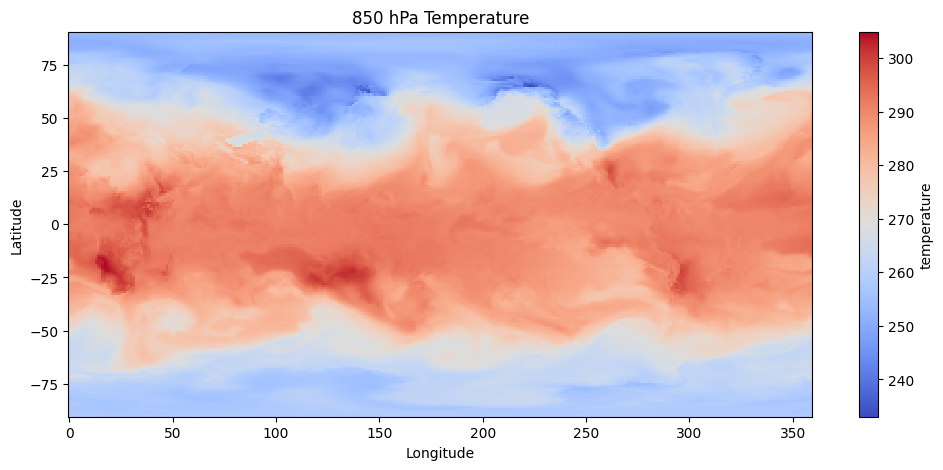

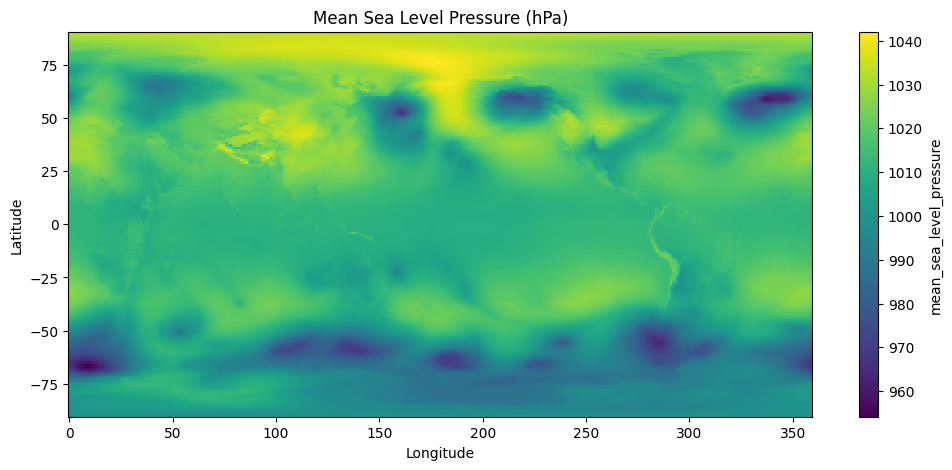

In [12]:
import matplotlib.pyplot as plt

# Extract 850 hPa temperature
temp_850 = predictions["temperature"].sel(level=850).isel(time=0, batch=0)

# Extract mean sea level pressure
mslp = predictions["mean_sea_level_pressure"].isel(time=0, batch=0) / 100.0  # Pa -> hPa

# Plot 850 hPa temperature
plt.figure(figsize=(12, 5))
temp_850.plot(cmap="coolwarm")
plt.title("850 hPa Temperature")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Plot mean sea level pressure
plt.figure(figsize=(12, 5))
mslp.plot(cmap="viridis")
plt.title("Mean Sea Level Pressure (hPa)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
